# Data Processing and Problem Formulation

This notebook implements the data processing pipeline for the geometric deep learning approach to momentum options trading, as described in Section 4 of the paper.

**Data Source:** WRDS OptionMetrics IvyDB (pre-filtered parquet files)

## Overview

The task is formulated as generating optimal trading signals $Y^{\delta \times 1 \times N}$ from a tensor of option features $X^{\delta \times F \times N}$:

$$X^{\delta \times F \times N} \Rightarrow f_\theta(G_\theta, X) \Rightarrow Y^{\delta \times 1 \times N}$$

Where:
- $\delta$ = number of time steps (trading days)
- $F$ = number of features
- $N$ = number of assets
- $f_\theta$ = deep learning model parameterized by $\theta$
- $G_\theta$ = graph structure (also parameterized)

This is a sequential decision-making problem optimized end-to-end to maximize risk-adjusted trading performance.

In [13]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.4.2
Pandas version: 2.2.3


In [14]:
# Import custom modules
import sys
sys.path.insert(0, '.')

from src.data_processing import (
    get_portfolio_formation_days,
    compute_delta_neutral_weights,
    create_synthetic_options_data,
    build_straddle_dataset,
    build_straddle_dataset_chunked,  # Memory-efficient version
    compute_returns,
    backfill_missing_ema
)

from src.features import (
    compute_volatility_normalized_returns,
    compute_volatility_normalized_macd,
    create_synthetic_features,
    create_synthetic_features_efficient,  # Memory-efficient version
    create_features_with_real_metadata,   # Uses real moneyness/TTE
    compute_feature_statistics,
    winsorize_ewm
)

from src.visualization import (
    plot_straddle_prices,
    plot_return_distributions,
    plot_sector_returns,
    plot_sector_pie_chart,
    plot_return_statistics_table,
    plot_correlation_heatmap,
    plot_feature_distributions,
    plot_cumulative_returns,
    create_summary_dashboard
)

print("Modules loaded successfully!")

Modules loaded successfully!


## 4.1 Problem Formulation

The problem is a sequential decision-making task where we generate trading signals without ground-truth labels. Rather than directly forecasting future straddle prices, models are optimized end-to-end to maximize risk-adjusted trading performance.

Key aspects:
- No explicit labels - this is a reinforcement learning / direct policy optimization task
- Model not dependent on predictive accuracy to generate positive returns
- Optimization metric is risk-adjusted performance (e.g., Sharpe ratio)

In [15]:
# Define problem dimensions
# Based on the paper: July 2011 - September 2023
# These will be updated after loading real data

START_DATE = '2011-07-01'
END_DATE = '2023-09-30'

# Expected dimensions (will be confirmed after data loading)
DELTA = 3118  # Trading days (approximate)
N = 88        # Assets (after filtering for 95% coverage)
F = 10        # Features

print(f"Target Problem Dimensions:")
print(f"  Time steps (delta): ~{DELTA}")
print(f"  Number of assets (N): ~{N}")
print(f"  Number of features (F): {F}")
print(f"\nFeature tensor shape: X ∈ R^(δ x {F} x N)")
print(f"Signal tensor shape:   Y ∈ R^(δ x 1 x N)")
print(f"\nNote: Actual dimensions will be confirmed after loading real data.")

Target Problem Dimensions:
  Time steps (delta): ~3118
  Number of assets (N): ~88
  Number of features (F): 10

Feature tensor shape: X ∈ R^(δ x 10 x N)
Signal tensor shape:   Y ∈ R^(δ x 1 x N)

Note: Actual dimensions will be confirmed after loading real data.


## 4.2 Dataset Overview

The dataset consists of S&P 100 equity option contracts from the OptionMetrics IvyDB database.

**Data Sources:**
- Options data: OptionMetrics IvyDB US (end-of-day bid-ask spreads, pricing, Greeks)
- Equity prices: CRSP (Center for Research in Security Prices)
- Corporate actions: CRSP US daily stock events

**Filtering criteria:**
- Exclude options with zero open interest
- Moneyness filter: 0.9 ≤ S/K (calls) or K/S (puts) ≤ 1.1
- Minimum 95% data coverage per asset

In [16]:
# S&P 100 tickers - reference list for sector mapping
# Actual tickers used will come from the loaded data

SP100_TICKERS = [
    'AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMT', 'AMZN',
    'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'BRK.B', 'C', 'CAT',
    'CHTR', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX',
    'DD', 'DHR', 'DIS', 'DOW', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD',
    'GE', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'INTC',
    'JNJ', 'JPM', 'KHC', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MA', 'MCD',
    'MDLZ', 'MDT', 'MET', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE',
    'NFLX', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'PM', 'PYPL', 'QCOM',
    'RTX', 'SBUX', 'SCHW', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TMUS', 'TSLA',
    'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WBA', 'WFC', 'WMT', 'AVGO', 'INTU'
]

# Sector mapping (GICS sectors) - used for visualization
SECTOR_MAP = {
    'AAPL': 'Information Technology', 'ABBV': 'Healthcare', 'ABT': 'Healthcare',
    'ACN': 'Information Technology', 'ADBE': 'Information Technology', 'AIG': 'Financials',
    'ALL': 'Financials', 'AMGN': 'Healthcare', 'AMT': 'Real Estate', 'AMZN': 'Consumer Discretionary',
    'AXP': 'Financials', 'BA': 'Industrials', 'BAC': 'Financials', 'BK': 'Financials',
    'BKNG': 'Consumer Discretionary', 'BLK': 'Financials', 'BMY': 'Healthcare', 'BRK.B': 'Financials',
    'C': 'Financials', 'CAT': 'Industrials', 'CHTR': 'Communication Services', 'CL': 'Consumer Staples',
    'CMCSA': 'Communication Services', 'COF': 'Financials', 'COP': 'Energy', 'COST': 'Consumer Staples',
    'CRM': 'Information Technology', 'CSCO': 'Information Technology', 'CVS': 'Healthcare', 'CVX': 'Energy',
    'DD': 'Materials', 'DHR': 'Healthcare', 'DIS': 'Communication Services', 'DOW': 'Materials',
    'DUK': 'Utilities', 'EMR': 'Industrials', 'EXC': 'Utilities', 'F': 'Consumer Discretionary',
    'FDX': 'Industrials', 'GD': 'Industrials', 'GE': 'Industrials', 'GILD': 'Healthcare',
    'GM': 'Consumer Discretionary', 'GOOG': 'Communication Services', 'GOOGL': 'Communication Services',
    'GS': 'Financials', 'HD': 'Consumer Discretionary', 'HON': 'Industrials', 'IBM': 'Information Technology',
    'INTC': 'Information Technology', 'JNJ': 'Healthcare', 'JPM': 'Financials', 'KHC': 'Consumer Staples',
    'KO': 'Consumer Staples', 'LIN': 'Materials', 'LLY': 'Healthcare', 'LMT': 'Industrials',
    'LOW': 'Consumer Discretionary', 'MA': 'Financials', 'MCD': 'Consumer Discretionary',
    'MDLZ': 'Consumer Staples', 'MDT': 'Healthcare', 'MET': 'Financials', 'META': 'Communication Services',
    'MMM': 'Industrials', 'MO': 'Consumer Staples', 'MRK': 'Healthcare', 'MS': 'Financials',
    'MSFT': 'Information Technology', 'NEE': 'Utilities', 'NFLX': 'Communication Services',
    'NKE': 'Consumer Discretionary', 'NVDA': 'Information Technology', 'ORCL': 'Information Technology',
    'PEP': 'Consumer Staples', 'PFE': 'Healthcare', 'PG': 'Consumer Staples', 'PM': 'Consumer Staples',
    'PYPL': 'Financials', 'QCOM': 'Information Technology', 'RTX': 'Industrials', 'SBUX': 'Consumer Discretionary',
    'SCHW': 'Financials', 'SO': 'Utilities', 'SPG': 'Real Estate', 'T': 'Communication Services',
    'TGT': 'Consumer Discretionary', 'TMO': 'Healthcare', 'TMUS': 'Communication Services',
    'TSLA': 'Consumer Discretionary', 'TXN': 'Information Technology', 'UNH': 'Healthcare',
    'UNP': 'Industrials', 'UPS': 'Industrials', 'USB': 'Financials', 'V': 'Financials',
    'VZ': 'Communication Services', 'WBA': 'Consumer Staples', 'WFC': 'Financials', 'WMT': 'Consumer Staples',
    'AVGO': 'Information Technology', 'INTU': 'Information Technology'
}

print(f"Reference S&P 100 tickers: {len(SP100_TICKERS)}")
print(f"Sector mappings available: {len(SECTOR_MAP)}")
print(f"\nNote: Actual tickers will be loaded from WRDS data in later cells.")

Reference S&P 100 tickers: 102
Sector mappings available: 102

Note: Actual tickers will be loaded from WRDS data in later cells.


## 4.3 Straddle Formation - Algorithm 1

We construct delta-neutral straddles following **Algorithm 1** from the paper.

### Algorithm 1: Straddle Prices & Returns Pipeline

```
Input: Equity options data for 100 underlying equities from July 2011 to September 2023

1:  for each asset i ∈ {1, 2, ..., 100} do
2:      for each PFD do
3:          select K_ATM and exdate for the following month
4:          filter options by K_ATM and exdate
5:          ŵ(i,call) = Δ(i,call) / (Δ(i,call) - Δ(i,put))     # normalized call weight
6:          ŵ(i,put) = -Δ(i,put) / (Δ(i,call) - Δ(i,put))      # normalized put weight
7:          for each trading day until next PFD do
8:              p(i,call)_t = (bid(i,call)_t + ask(i,call)_t) / 2    # call mid price
9:              p(i,put)_t = (bid(i,put)_t + ask(i,put)_t) / 2       # put mid price
10:             p(i,V)_t = ŵ(i,call) * p(i,call)_t + ŵ(i,put) * p(i,put)_t  # Δ-neutral straddle price
11:         end for
12:         roll p(i,V)_t from front to back month
13:     end for
14: end for
15: discard assets with less than 95% data coverage
16: for each remaining asset i ∈ {1, 2, ..., N} do
17:     for each trading day do
18:         fill p(i,V)_t with 5-day EMA if missing
19:         r(i,V)_{t+1,t} = (p(i,V)_{t+1} - p(i,V)_t) / p(i,V)_t   # Δ-neutral straddle return
20:     end for
21: end for

Output: P, R ∈ R^{δ×N}  (straddle prices & returns)
```

In [17]:
# Demonstrate Portfolio Formation Day calculation (Line 2)
pfds = get_portfolio_formation_days(START_DATE, END_DATE)

print(f"Portfolio Formation Days (PFDs) - 2nd Monday of each month:")
print(f"  Total PFDs: {len(pfds)}")
print(f"  First 5: {[d.strftime('%Y-%m-%d (%A)') for d in pfds[:5]]}")
print(f"  Last 5:  {[d.strftime('%Y-%m-%d (%A)') for d in pfds[-5:]]}")

Portfolio Formation Days (PFDs) - 2nd Monday of each month:
  Total PFDs: 147
  First 5: ['2011-07-11 (Monday)', '2011-08-08 (Monday)', '2011-09-12 (Monday)', '2011-10-10 (Monday)', '2011-11-14 (Monday)']
  Last 5:  ['2023-05-08 (Monday)', '2023-06-12 (Monday)', '2023-07-10 (Monday)', '2023-08-14 (Monday)', '2023-09-11 (Monday)']


In [18]:
# Demonstrate delta-neutral weight calculation (Lines 5-6)
# ŵ(i,call) = Δ(i,call) / (Δ(i,call) - Δ(i,put))
# ŵ(i,put) = -Δ(i,put) / (Δ(i,call) - Δ(i,put))

example_deltas = [
    (0.50, -0.50),   # ATM: equal weights
    (0.55, -0.45),   # Slightly ITM call
    (0.45, -0.55),   # Slightly OTM call
    (0.70, -0.30),   # Deep ITM call
]

print("Delta-Neutral Weight Calculation (Algorithm 1, Lines 5-6):")
print("="*65)
print(f"{'Δ_call':>10} {'Δ_put':>10} {'ŵ_call':>12} {'ŵ_put':>12} {'Net Δ':>10}")
print("="*65)

for delta_call, delta_put in example_deltas:
    w_call, w_put = compute_delta_neutral_weights(delta_call, delta_put)
    net_delta = w_call * delta_call + w_put * delta_put
    print(f"{delta_call:>10.2f} {delta_put:>10.2f} {w_call:>12.4f} {w_put:>12.4f} {net_delta:>10.6f}")

print("\nNote: Net delta ≈ 0 ensures the position is delta-neutral.")

Delta-Neutral Weight Calculation (Algorithm 1, Lines 5-6):
    Δ_call      Δ_put       ŵ_call        ŵ_put      Net Δ
      0.50      -0.50       0.5000       0.5000   0.000000
      0.55      -0.45       0.5500       0.4500   0.100000
      0.45      -0.55       0.4500       0.5500  -0.100000
      0.70      -0.30       0.7000       0.3000   0.400000

Note: Net delta ≈ 0 ensures the position is delta-neutral.


In [19]:
# Load REAL options data from filtered parquet files
# MEMORY-EFFICIENT VERSION: Load only required columns and process incrementally

from pathlib import Path
import pyarrow.parquet as pq
import gc

print("Loading real options data from WRDS (memory-efficient)...")

# Configuration
RAW_DATA_DIR = Path('raw_data')
FILTERED_DIR = RAW_DATA_DIR / 'options_filtered_by_year'
START_YEAR = 2011
END_YEAR = 2023

# Only load columns actually needed for straddle construction
REQUIRED_COLUMNS = [
    'secid', 'date', 'exdate', 'cp_flag', 'strike_price',
    'best_bid', 'best_offer', 'delta', 'spot_price'
]

# Load security names to map secid -> ticker
secnames_df = pd.read_parquet(RAW_DATA_DIR / 'security_names.parquet')
secid_to_ticker = dict(zip(secnames_df['secid'].astype(int), secnames_df['ticker']))
del secnames_df  # Free immediately
print(f"Loaded {len(secid_to_ticker)} security mappings")

# Load options data year by year, keeping only required columns
options_dfs = []
total_records = 0

for year in range(START_YEAR, END_YEAR + 1):
    fpath = FILTERED_DIR / f'options_filtered_{year}.parquet'
    if fpath.exists():
        # Read only required columns using PyArrow (much faster & less memory)
        table = pq.read_table(fpath, columns=REQUIRED_COLUMNS)
        df = table.to_pandas()
        del table  # Free PyArrow memory immediately
        
        options_dfs.append(df)
        total_records += len(df)
        print(f"  {year}: {len(df):,} records")

# Concatenate with copy=False to avoid doubling memory
print(f"\nConcatenating {len(options_dfs)} years...")
options_df = pd.concat(options_dfs, ignore_index=True, copy=False)

# MEMORY OPTIMIZATION: Delete the list immediately after concat
del options_dfs
gc.collect()

# MEMORY OPTIMIZATION: Convert to float32 to halve memory usage
print("Converting to float32 for memory efficiency...")
float_cols = ['best_bid', 'best_offer', 'delta', 'spot_price', 'strike_price']
for col in float_cols:
    if col in options_df.columns:
        options_df[col] = options_df[col].astype('float32')

print(f"\nTotal options records: {len(options_df):,}")
print(f"Date range: {options_df['date'].min().date()} to {options_df['date'].max().date()}")
print(f"Unique securities: {options_df['secid'].nunique()}")
print(f"Memory usage: {options_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading real options data from WRDS (memory-efficient)...
Loaded 87 security mappings
  2011: 1,452,407 records
  2012: 1,665,902 records
  2013: 2,596,040 records
  2014: 4,226,163 records
  2015: 5,084,197 records
  2016: 5,158,134 records
  2017: 5,536,621 records
  2018: 6,153,349 records
  2019: 6,376,102 records
  2020: 6,360,620 records
  2021: 6,687,680 records
  2022: 5,938,605 records
  2023: 5,929,889 records

Concatenating 13 years...
Converting to float32 for memory efficiency...

Total options records: 63,165,709
Date range: 2011-01-03 to 2023-12-29
Unique securities: 87
Memory usage: 2469.8 MB


In [20]:
# Adapt data format to match pipeline expectations
# Map secid -> ticker and rename columns

print("Adapting data format...")

# Map secid to ticker
options_df['ticker'] = options_df['secid'].map(secid_to_ticker)

# Check for unmapped securities
unmapped = options_df['ticker'].isna().sum()
if unmapped > 0:
    print(f"Warning: {unmapped:,} records have unmapped secid")
    options_df = options_df.dropna(subset=['ticker'])

# Rename strike_price to strike (expected by pipeline)
options_df = options_df.rename(columns={'strike_price': 'strike'})

# Build equity price DataFrame (pivot spot_price by ticker and date)
# This is needed for the straddle building pipeline
print("\nBuilding equity price matrix...")
equity_df = options_df.groupby(['date', 'ticker'])['spot_price'].first().unstack()
equity_df = equity_df.sort_index()

# MEMORY OPTIMIZATION: Force garbage collection after creating equity_df
gc.collect()

print(f"\nEquity price matrix shape: {equity_df.shape}")
print(f"  Dates: {len(equity_df)} trading days")
print(f"  Tickers: {len(equity_df.columns)} securities")

# Show sample of adapted options data
print("\nAdapted Options Data Structure:")
print("="*60)
print(options_df[['date', 'ticker', 'exdate', 'strike', 'cp_flag', 
                  'best_bid', 'best_offer', 'delta']].head(5).to_string())

# Update DEMO_TICKERS to use actual tickers from the data
DEMO_TICKERS = sorted(options_df['ticker'].unique().tolist())
print(f"\nAvailable tickers ({len(DEMO_TICKERS)}): {DEMO_TICKERS[:10]}...")

# Memory status
gc.collect()
print(f"\nCurrent memory usage: {options_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Adapting data format...

Building equity price matrix...

Equity price matrix shape: (3270, 87)
  Dates: 3270 trading days
  Tickers: 87 securities

Adapted Options Data Structure:
        date ticker     exdate  strike cp_flag  best_bid  best_offer  delta
0 2011-01-03    ABT 2011-01-22 44.0000       C    3.8000      3.9000 0.9665
1 2011-01-03    ABT 2011-01-22 45.0000       C    2.8100      2.9000 0.9527
2 2011-01-03    ABT 2011-01-22 46.0000       C    1.9000      1.9400 0.8728
3 2011-01-03    ABT 2011-01-22 47.0000       C    1.0500      1.0900 0.7117
4 2011-01-03    ABT 2011-01-22 48.0000       C    0.4600      0.4800 0.4384

Available tickers (87): ['AAPL', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMGN', 'AMT', 'AMZN', 'AVGO', 'AXP']...

Current memory usage: 5610.9 MB


In [21]:
# Show example of call/put pair at same strike from REAL data
# Filter to options with valid delta for the example

valid_delta_mask = options_df['delta'].notna()
options_with_delta = options_df[valid_delta_mask]

if len(options_with_delta) > 0:
    sample_ticker = options_with_delta['ticker'].iloc[0]
    sample_date = options_with_delta['date'].iloc[0]
    
    # Find a strike with both call and put
    sample_opts = options_with_delta[
        (options_with_delta['ticker'] == sample_ticker) & 
        (options_with_delta['date'] == sample_date)
    ]
    
    # Group by strike and find one with both C and P
    strike_counts = sample_opts.groupby('strike')['cp_flag'].nunique()
    valid_strikes = strike_counts[strike_counts == 2].index
    
    if len(valid_strikes) > 0:
        sample_strike = valid_strikes[0]
        pair = sample_opts[sample_opts['strike'] == sample_strike].sort_values('cp_flag')
        
        print(f"Example Call/Put Pair for {sample_ticker} on {sample_date.date()}:")
        print(f"Strike: ${sample_strike:.2f}")
        print("="*70)
        display(pair[['cp_flag', 'best_bid', 'best_offer', 'delta']])

        # Calculate straddle price
        call_row = pair[pair['cp_flag'] == 'C'].iloc[0]
        put_row = pair[pair['cp_flag'] == 'P'].iloc[0]

        w_call, w_put = compute_delta_neutral_weights(call_row['delta'], put_row['delta'])
        call_mid = (call_row['best_bid'] + call_row['best_offer']) / 2
        put_mid = (put_row['best_bid'] + put_row['best_offer']) / 2
        straddle_price = w_call * call_mid + w_put * put_mid

        print(f"\nAlgorithm 1 Calculation (Lines 5-10):")
        print(f"  Call Δ = {call_row['delta']:.4f}, Put Δ = {put_row['delta']:.4f}")
        print(f"  ŵ_call = {w_call:.4f}, ŵ_put = {w_put:.4f}")
        print(f"  Call mid = (${call_row['best_bid']:.2f} + ${call_row['best_offer']:.2f})/2 = ${call_mid:.2f}")
        print(f"  Put mid  = (${put_row['best_bid']:.2f} + ${put_row['best_offer']:.2f})/2 = ${put_mid:.2f}")
        print(f"  Straddle price = {w_call:.4f} × ${call_mid:.2f} + {w_put:.4f} × ${put_mid:.2f} = ${straddle_price:.2f}")
    else:
        print("No valid call/put pairs found with delta data for example")
else:
    print("No options with valid delta found for example")
    print(f"Options with missing delta: {(~valid_delta_mask).sum():,} / {len(options_df):,}")

Example Call/Put Pair for ABT on 2011-01-03:
Strike: $44.00


,cp_flag,best_bid,best_offer,delta
0,C,3.8000,3.9000,0.9665
16,C,3.8500,3.9500,0.9182
32,C,4.2500,4.3500,0.7578
48,C,4.7000,4.8000,0.6969
8,P,0.0900,0.1000,-0.0796
24,P,0.3100,0.3300,-0.1582
40,P,1.0700,1.1100,-0.2740
56,P,1.8400,1.8800,-0.3253



Algorithm 1 Calculation (Lines 5-10):
  Call Δ = 0.9665, Put Δ = -0.0796
  ŵ_call = 0.9239, ŵ_put = 0.0761
  Call mid = ($3.80 + $3.90)/2 = $3.85
  Put mid  = ($0.09 + $0.10)/2 = $0.09
  Straddle price = 0.9239 × $3.85 + 0.0761 × $0.09 = $3.56


## Running the Full Algorithm 1 Pipeline

Now we run the complete `build_straddle_dataset` function which implements Algorithm 1:

1. **Lines 1-14**: For each asset and each PFD, select ATM options, compute delta-neutral weights, calculate straddle prices
2. **Line 15**: Discard assets with < 95% data coverage
3. **Lines 16-20**: Fill missing values with 5-day EMA, compute returns

In [ ]:
# MEMORY CLEANUP - Run BEFORE Algorithm 1
import gc

# 1. Delete the demo variable from cell-12 if it exists
try:
    del options_with_delta
    del sample_opts
    del pair
except NameError:
    pass

# 2. Convert to efficient dtypes (if not already done)
options_df['ticker'] = options_df['ticker'].astype('category')
options_df['cp_flag'] = options_df['cp_flag'].astype('category')

# 3. Filter IN-PLACE instead of making a copy
# options_df = options_df[options_df['delta'].notna()]

# 4. Delete unused columns if any
keep_cols = ['date', 'ticker', 'exdate', 'strike', 'cp_flag',
            'best_bid', 'best_offer', 'delta']
options_df = options_df[keep_cols]

# 5. Force garbage collection
gc.collect()

print(f"Options data reduced to: {len(options_df):,} rows")
print(f"Memory: {options_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Change this line:
# options_valid = options_df[options_df['delta'].notna()].copy()  # BAD - creates copy!

# To this:
options_valid = options_df  # Already filtered above, no copy needed

Options data reduced to: 59,269,823 rows
Memory: 2374.0 MB


In [ ]:
import importlib
import src.data_processing
importlib.reload(src.data_processing)
from src.data_processing import build_straddle_dataset_chunked, load_cfacpr_data, apply_split_adjustment, compute_split_adjustment_factors

In [24]:
# Run Algorithm 1 to build straddle price and return matrices
# Using REAL data - MEMORY-EFFICIENT CHUNKED VERSION with PRICE STITCHING

from src.data_processing import (
    build_straddle_dataset_chunked,
    load_cfacpr_data,
    apply_split_adjustment,
    compute_split_adjustment_factors
)

print("Running Algorithm 1: Straddle Prices & Returns Pipeline")
print("="*60)

# Check data quality before processing
total_options = len(options_df)
valid_delta = options_df['delta'].notna().sum()
print(f"\nData quality check:")
print(f"  Total options: {total_options:,}")
print(f"  With valid delta: {valid_delta:,} ({100*valid_delta/total_options:.1f}%)")
print(f"  Missing delta: {total_options - valid_delta:,} ({100*(1-valid_delta/total_options):.1f}%)")

options_valid = options_df
print(f"\nUsing {len(options_valid):,} options with valid delta")

# Paper specifies 95% coverage threshold (Algorithm 1, Line 15)
MIN_COVERAGE = 0.95
CHUNK_SIZE = 10

# Load cfacpr data for split detection
print("\nLoading split adjustment factors (cfacpr)...")
cfacpr_data = load_cfacpr_data(
    'raw_data/equity_prices_raw.parquet',
    'raw_data/security_names.parquet',
    tickers=list(equity_df.columns)
)

print(f"\nStep 1-14: Processing each asset at each PFD...")
print(f"  - Using chunked processing (chunk_size={CHUNK_SIZE}) for memory efficiency")
print(f"  - Selecting ATM strike for FOLLOWING MONTH expiration (per paper)")
print(f"  - Computing delta-neutral weights")
print(f"  - Calculating straddle prices from bid-ask midpoints")
print(f"  - STITCHING prices at PFD roll boundaries (Algorithm 1, Line 12)")
print(f"  - Split-aware strike tracking enabled\n")

DEBUG_TICKERS = list(equity_df.columns[:2])
equity_df_debug = equity_df[DEBUG_TICKERS]
options_valid_debug = options_valid[options_valid['ticker'].isin(DEBUG_TICKERS)]

# Build straddle dataset WITH split-aware option tracking
straddle_prices, straddle_returns, straddle_metadata = build_straddle_dataset_chunked(
    options_df=options_valid_debug,
    equity_df=equity_df_debug,
    min_coverage=MIN_COVERAGE,
    chunk_size=CHUNK_SIZE,
    verbose=True,
    return_metadata=True,
    cfacpr_data=cfacpr_data
)

print(f"\nStep 15: Coverage filter applied (min {MIN_COVERAGE*100:.0f}%)")
print(f"  Assets passing filter: {len(straddle_prices.columns)} / {len(DEMO_TICKERS)}")

# Apply split adjustment to normalize price levels
print(f"\nApplying split adjustment to normalize price levels...")
adj_factors = compute_split_adjustment_factors(
    'raw_data/equity_prices_raw.parquet',
    'raw_data/security_names.parquet',
    tickers=list(straddle_prices.columns)
)
straddle_prices = apply_split_adjustment(straddle_prices, adj_factors)

# Recompute returns from adjusted prices
straddle_returns = straddle_prices.pct_change()

print(f"\nStep 16-20: Post-processing")
print(f"  - Missing values filled with 5-day EMA")
print(f"  - Split adjustment applied")
print(f"  - Returns recomputed from adjusted prices")

print(f"\n" + "="*60)
print(f"OUTPUT: P, R ∈ R^{{δ×N}}")
print(f"  Straddle prices shape: {straddle_prices.shape}")
print(f"  Straddle returns shape: {straddle_returns.shape}")
if straddle_metadata:
    print(f"  Metadata: strike, exdate, spot DataFrames for real features")

print(f"\nAssets included ({len(straddle_prices.columns)}):")
print(f"  {list(straddle_prices.columns)}")

Running Algorithm 1: Straddle Prices & Returns Pipeline

Data quality check:
  Total options: 59,269,823
  With valid delta: 59,269,823 (100.0%)
  Missing delta: 0 (0.0%)

Using 59,269,823 options with valid delta

Loading split adjustment factors (cfacpr)...

Step 1-14: Processing each asset at each PFD...
  - Using chunked processing (chunk_size=10) for memory efficiency
  - Selecting ATM strike for FOLLOWING MONTH expiration (per paper)
  - Computing delta-neutral weights
  - Calculating straddle prices from bid-ask midpoints
  - STITCHING prices at PFD roll boundaries (Algorithm 1, Line 12)
  - Split-aware strike tracking enabled

  Processing tickers 1-2 of 2...
    AAPL: PFDs=155/155, no_spot=0, no_opts=0, no_exp=0, no_strike=0, no_cp=30, no_data=0, periods=125
        stitch: front=17, back=9, front_before=17, back_after=9
        stitch: front=26, back=10, front_before=26, back_after=10
      -> AAPL coverage: 1906/3371 = 56.5% (need 95%), pfds[0]=2011-01-10, pfds[-1]=2023-12-1

ValueError: No assets met the coverage requirement

In [ ]:
# MEMORY CLEANUP: Free large DataFrames no longer needed
# options_df and options_valid were only needed for straddle construction

print("Cleaning up memory after straddle construction...")
mem_before = 0
try:
    mem_before = options_df.memory_usage(deep=True).sum() / 1024**2
    del options_df
except NameError:
    pass

try:
    del options_valid
except NameError:
    pass

try:
    del secid_to_ticker
except NameError:
    pass

gc.collect()
print(f"Freed approximately {mem_before:.1f} MB")
print("Retained: straddle_prices, straddle_returns, equity_df")

Cleaning up memory after straddle construction...


NameError: name 'gc' is not defined

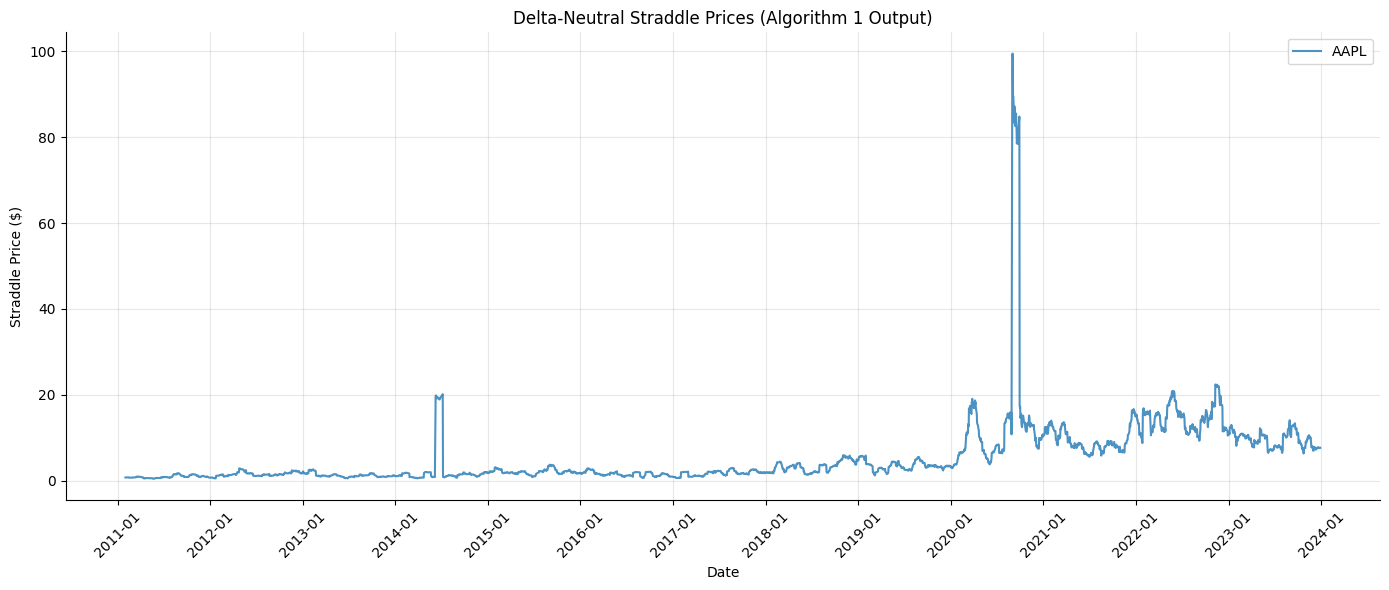

In [ ]:
# Visualize sample straddle prices
sample_tickers = list(straddle_prices.columns[:1])
fig = plot_straddle_prices(
    straddle_prices,
    tickers=sample_tickers,
    title='Delta-Neutral Straddle Prices (Algorithm 1 Output)'
)
plt.show()

In [ ]:
# Verify the straddle price calculation step-by-step for one asset
print("Verification: Straddle Price Calculation Trace")
print("="*60)

if len(straddle_prices.columns) > 0:
    ticker = straddle_prices.columns[0]
    print(f"\nAsset: {ticker}")
    print(f"First 5 straddle prices:")
    print(straddle_prices[ticker].head())
    
    print(f"\nFirst 5 straddle returns:")
    print(straddle_returns[ticker].head())
    
    # Verify return calculation
    p0 = straddle_prices[ticker].iloc[0]
    p1 = straddle_prices[ticker].iloc[1]
    manual_return = (p1 - p0) / p0
    computed_return = straddle_returns[ticker].iloc[1]
    
    print(f"\nReturn verification:")
    print(f"  p_0 = ${p0:.4f}")
    print(f"  p_1 = ${p1:.4f}")
    print(f"  Manual: (p_1 - p_0)/p_0 = {manual_return:.6f}")
    print(f"  Computed: {computed_return:.6f}")
    print(f"  Match: {np.isclose(manual_return, computed_return)}")

Verification: Straddle Price Calculation Trace

Asset: AAPL
First 5 straddle prices:
date
2011-02-01   21.3728
2011-02-02   21.3545
2011-02-03   21.2364
2011-02-04   21.5529
2011-02-07   22.3212
Name: AAPL, dtype: float64

First 5 straddle returns:
date
2011-02-01       NaN
2011-02-02   -0.0009
2011-02-03   -0.0055
2011-02-04    0.0149
2011-02-07    0.0357
Name: AAPL, dtype: float64

Return verification:
  p_0 = $21.3728
  p_1 = $21.3545
  Manual: (p_1 - p_0)/p_0 = -0.000859
  Computed: -0.000859
  Match: True


## 4.3.1 Feature Data

The feature tensor $X \in \mathbb{R}^{\delta \times F \times N}$ contains F=10 features:

**Volatility-Normalized Returns** (5 features):
$$r_{t-k,t}^{(i,V)} / (\sigma_t^{(i,V)} \cdot \sqrt{k}), \quad k \in \{1, 5, 10, 15, 20\}$$

**Volatility-Normalized MACD** (3 features):
$$I_{MACD,t}^{(i,V)}(S,L), \quad (S,L) \in \{(2,8), (4,16), (8,32)\}$$

**Option Features** (2 features):
- Log-moneyness: $\log(S/K)$
- Time-to-expiry (years)

All features are winsorized using EWM statistics with 252-day half-life and $\pm 5\sigma$ floor/cap.

In [ ]:
# Build feature tensor using REAL metadata when available
print("Computing features (Section 4.3.1)...")
print("="*60)

if straddle_metadata is not None:
    # Use REAL moneyness and time-to-expiry from actual option data
    print("Using REAL option metadata (strike, expiry, spot) for features!")
    print("  - Log-moneyness: log(S/K) computed from actual data")
    print("  - Time-to-expiry: actual days to expiration / 252")

    feature_tensor, feature_names = create_features_with_real_metadata(
        prices=straddle_prices,
        returns=straddle_returns,
        metadata=straddle_metadata,
        return_horizons=[1, 5, 10, 15, 20],
        macd_params=[(2, 8), (4, 16), (8, 32)],
        dtype=np.float32
    )
else:
    # Fallback to synthetic features (if no metadata available)
    print("Warning: No metadata available, using SYNTHETIC features")
    print("  - Log-moneyness: random ATM approximation")
    print("  - Time-to-expiry: synthetic monthly cycle")

    feature_tensor, feature_names = create_synthetic_features_efficient(
        prices=straddle_prices,
        returns=straddle_returns,
        return_horizons=[1, 5, 10, 15, 20],
        macd_params=[(2, 8), (4, 16), (8, 32)],
        include_moneyness=True,
        include_tte=True,
        dtype=np.float32
    )

# Force cleanup after feature creation
gc.collect()

print(f"\nFeature tensor X ∈ R^{{δ × F × N}}:")
print(f"  Shape: {feature_tensor.shape}")
print(f"  δ (time steps): {feature_tensor.shape[0]}")
print(f"  F (features):   {feature_tensor.shape[1]}")
print(f"  N (assets):     {feature_tensor.shape[2]}")
print(f"  Dtype: {feature_tensor.dtype}")
print(f"  Memory: {feature_tensor.nbytes / 1024**2:.1f} MB")

print(f"\nFeature names ({len(feature_names)}):")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2d}. {name}")

In [ ]:
# Compute feature statistics
feature_stats = compute_feature_statistics(feature_tensor, feature_names)

print("Feature Statistics (after winsorization):")
display(feature_stats)

In [ ]:
# Plot feature distributions
fig = plot_feature_distributions(feature_tensor, feature_names, figsize=(16, 10))
plt.show()

## 4.4 Analysis of Processed Data

### Return Statistics

Key observations from the paper:
- All returns exhibit **negative mean** (theta decay)
- **Negative median** with **positive skewness** (limited downside, unbounded upside for long straddle)
- **High kurtosis** for daily returns (fat tails)

In [ ]:
# Compute returns at different horizons
daily_returns = straddle_returns.copy()

weekly_returns = straddle_returns.rolling(window=5).apply(
    lambda x: (1 + x).prod() - 1, raw=True
)

monthly_returns = straddle_returns.rolling(window=20).apply(
    lambda x: (1 + x).prod() - 1, raw=True
)

horizons = {
    'Daily': daily_returns,
    'Weekly': weekly_returns,
    'Monthly': monthly_returns
}

# Plot return distributions
fig = plot_return_distributions(daily_returns, horizons, figsize=(14, 4))
plt.suptitle('Straddle Return Distributions (Figure 2 from paper)', fontsize=12, y=1.02)
plt.show()

In [ ]:
# Create return statistics table (Figure 3b from paper)
fig = plot_return_statistics_table(straddle_returns)
plt.show()

In [ ]:
# Sector pie chart (Figure 3a from paper)
# Only include tickers that are in both our data and the sector map

sector_counts_filtered = {}
tickers_with_sector = []
tickers_without_sector = []

for ticker in straddle_prices.columns:
    if ticker in SECTOR_MAP:
        sector = SECTOR_MAP[ticker]
        sector_counts_filtered[sector] = sector_counts_filtered.get(sector, 0) + 1
        tickers_with_sector.append(ticker)
    else:
        tickers_without_sector.append(ticker)

if tickers_without_sector:
    print(f"Note: {len(tickers_without_sector)} tickers not in sector map: {tickers_without_sector[:5]}...")

if sector_counts_filtered:
    fig = plot_sector_pie_chart(sector_counts_filtered, title='Assets by Sector')
    plt.show()
else:
    print("No tickers with sector mapping found")

### 4.4.2 Motivating Geometric Deep Learning

The sector-averaged returns show clear correlation structure (Figure 5 from paper), motivating the use of graph-based methods to capture:
- Cross-sectional momentum spillover
- Inter-asset volatility dependencies
- Sector-level risk factors

In [ ]:
# Compute volatility-normalized monthly returns for sector analysis
vol_20d = straddle_returns.rolling(window=20).std()
vol_20d = vol_20d.replace(0, np.nan)
normalized_monthly = monthly_returns / (vol_20d * np.sqrt(20))

# Plot sector returns (similar to Figure 5 in paper)
fig = plot_sector_returns(
    normalized_monthly,
    SECTOR_MAP,
    title='Sector-Averaged Volatility-Normalized Monthly Returns'
)
plt.show()

In [ ]:
# Plot correlation heatmap to show cross-asset dependencies
fig = plot_correlation_heatmap(
    straddle_returns.dropna(),
    title='Straddle Return Correlations'
)
plt.show()

print("\nObservation: Clear sector-level correlation clusters motivate")
print("the use of graph-based methods to capture inter-asset relationships.")

In [ ]:
# Create summary dashboard
fig = create_summary_dashboard(
    straddle_prices,
    straddle_returns,
    SECTOR_MAP
)
plt.show()

## Summary

This notebook implements **Algorithm 1** from the paper for data processing:

### Algorithm 1 Implementation Summary

| Step | Description | Implementation |
|------|-------------|----------------|
| 1-14 | Process each asset at each PFD | `process_single_asset()` |
| 3 | Select ATM strike and expiration | `select_atm_strike()` |
| 5-6 | Compute delta-neutral weights | `compute_delta_neutral_weights()` |
| 8-10 | Calculate straddle prices | `compute_straddle_price()` |
| 12 | Roll contracts | `stitch_price_series()` |
| 15 | Filter by coverage | `min_coverage` parameter |
| 18 | Fill missing with EMA | `backfill_missing_ema()` |
| 19 | Compute returns | `compute_returns()` |

### Output Tensors

- **Prices**: $P \in \mathbb{R}^{\delta \times N}$
- **Returns**: $R \in \mathbb{R}^{\delta \times N}$
- **Features**: $X \in \mathbb{R}^{\delta \times F \times N}$

In [ ]:
# Final summary of processed data
print("=" * 60)
print("ALGORITHM 1 OUTPUT SUMMARY (REAL DATA)")
print("=" * 60)
print(f"\nPrice Matrix P ∈ R^{{δ×N}}:")
print(f"  Shape: {straddle_prices.shape}")
print(f"  δ = {straddle_prices.shape[0]} trading days")
print(f"  N = {straddle_prices.shape[1]} assets")
print(f"  Date range: {straddle_prices.index.min().date()} to {straddle_prices.index.max().date()}")

print(f"\nReturn Matrix R ∈ R^{{δ×N}}:")
print(f"  Shape: {straddle_returns.shape}")
print(f"  Mean daily return: {straddle_returns.mean().mean():.6f}")
print(f"  Std daily return:  {straddle_returns.std().mean():.6f}")

print(f"\nFeature Tensor X ∈ R^{{δ×F×N}}:")
print(f"  Shape: {feature_tensor.shape}")
print(f"  F = {len(feature_names)} features")

print(f"\nData Source: WRDS OptionMetrics IvyDB")
print(f"Assets: {list(straddle_prices.columns)}")
print("=" * 60)

In [ ]:
# Save processed data for downstream tasks
import os
import json

output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)

# Save as numpy arrays
np.save(f'{output_dir}/straddle_prices.npy', straddle_prices.values)
np.save(f'{output_dir}/straddle_returns.npy', straddle_returns.values)
np.save(f'{output_dir}/feature_tensor.npy', feature_tensor)

# Save underlying equity prices for graph construction (Pearson correlation)
# Filter equity_df to only include tickers in straddle_prices
# NEW - uses split-adjusted prices from CRSP
equity_raw = pd.read_parquet('raw_data/equity_prices_raw.parquet')
secnames = pd.read_parquet('raw_data/security_names.parquet')

secid_to_ticker = dict(zip(secnames['secid'].astype(int), secnames['ticker']))

equity_raw['adjusted_price'] = equity_raw['prc'].abs() / equity_raw['cfacpr']
equity_raw['ticker'] = equity_raw['secid'].map(secid_to_ticker)
equity_raw['date'] = pd.to_datetime(equity_raw['date'])

equity_adjusted = equity_raw.pivot(index='date', columns='ticker', values='adjusted_price')
equity_adjusted = equity_adjusted[straddle_prices.columns]
equity_adjusted = equity_adjusted.loc[straddle_prices.index]

np.save(f'{output_dir}/equity_prices.npy', equity_adjusted.values)
equity_adjusted.to_csv(f'{output_dir}/equity_prices.csv')

# Save DataFrames as CSV for inspection
straddle_prices.to_csv(f'{output_dir}/straddle_prices.csv')
straddle_returns.to_csv(f'{output_dir}/straddle_returns.csv')

# Save metadata
metadata = {
    'tickers': list(straddle_prices.columns),
    'dates': [str(d) for d in straddle_prices.index],
    'equity_dates': [str(d) for d in equity_adjusted.index],
    'feature_names': feature_names,
    'sector_map': {k: v for k, v in SECTOR_MAP.items() if k in straddle_prices.columns},
    'dimensions': {
        'delta': int(straddle_prices.shape[0]),
        'N': int(straddle_prices.shape[1]),
        'F': len(feature_names),
        'equity_days': int(equity_adjusted.shape[0])
    },
    'data_source': 'WRDS OptionMetrics IvyDB',
    'date_range': {
        'start': str(straddle_prices.index.min().date()),
        'end': str(straddle_prices.index.max().date())
    }
}

with open(f'{output_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved processed data to '{output_dir}/' directory:")
for fname in sorted(os.listdir(output_dir)):
    fpath = os.path.join(output_dir, fname)
    fsize = os.path.getsize(fpath)
    if fsize > 1024*1024:
        print(f"  - {fname} ({fsize/1024/1024:.1f} MB)")
    else:
        print(f"  - {fname} ({fsize/1024:.1f} KB)")